# 08. Sliding Window Merge (슬라이딩 윈도우 + 통합)

## 목적
1. 코호트 기준 슬라이딩 윈도우 생성
2. 모든 raw 테이블을 윈도우 기준으로 집계 & 병합
3. 레이블 생성 (death, vent, pressor)

## 입력 (Raw 테이블들)
- `sepsis_cohort.csv`: 기본 코호트
- `vital_raw.csv`: 활력징후
- `lab_raw.csv`: 검사 결과
- `ventilation_raw.csv`: 인공호흡기
- `pressor_raw.csv`: 승압제
- `urine_raw.csv`: 소변량
- `gcs_raw.csv`: GCS 점수

## 출력
- `sliding_window_merged.csv`: 슬라이딩 윈도우 통합 데이터

## 윈도우 설정
- **Window Size**: 6시간
- **Stride**: 1시간
- **Range**: ICU 입실 후 6h ~ 72h
- **예상 결과**: ~93만 rows (약 23K 환자 × 약 40 시점)

In [29]:
from pathlib import Path
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
import pandas as pd
import numpy as np
import os
from datetime import timedelta

# 설정
INPUT_DIR = PROCESSED_DIR
OUTPUT_DIR = PROCESSED_DIR

# 윈도우 파라미터
WINDOW_SIZE_H = 6   # 윈도우 크기 (시간)
STRIDE_H = 1        # 이동 간격 (시간)
MIN_HOUR = 6        # 시작 시점 (ICU 입실 후)
MAX_HOUR = 72       # 종료 시점

print("=== 10. Sliding Window Merge 시작 ===")
print(f"\n윈도우 설정:")
print(f"  - Window Size: {WINDOW_SIZE_H}h")
print(f"  - Stride: {STRIDE_H}h")
print(f"  - Range: {MIN_HOUR}h ~ {MAX_HOUR}h")

=== 10. Sliding Window Merge 시작 ===

윈도우 설정:
  - Window Size: 6h
  - Stride: 1h
  - Range: 6h ~ 72h


## Step 1: 코호트 및 Raw 테이블 로드

In [30]:
print("\nStep 1: 데이터 로드")

# 코호트
df_cohort = pd.read_csv(
    INPUT_DIR / "sepsis_cohort.csv",
    parse_dates=['intime', 'outtime', 'deathtime', 'dnr_time', 'vent_start_time', 'pressor_start_time']
)
print(f"✓ sepsis_cohort: {len(df_cohort):,}명")

# Raw 테이블들
df_vital = pd.read_csv(INPUT_DIR / "vital_raw.csv", parse_dates=['charttime_h'])
print(f"✓ vital_raw: {len(df_vital):,} rows")

df_lab = pd.read_csv(INPUT_DIR / "lab_raw.csv", parse_dates=['charttime_h'])
print(f"✓ lab_raw: {len(df_lab):,} rows")

df_vent = pd.read_csv(INPUT_DIR / "ventilation_raw.csv", parse_dates=['charttime_h'])
print(f"✓ ventilation_raw: {len(df_vent):,} rows")

df_pressor = pd.read_csv(INPUT_DIR / "pressor_raw.csv", parse_dates=['charttime_h'])
print(f"✓ pressor_raw: {len(df_pressor):,} rows")

df_urine = pd.read_csv(INPUT_DIR / "urine_raw.csv", parse_dates=['charttime_h'])
print(f"✓ urine_raw: {len(df_urine):,} rows")

df_gcs = pd.read_csv(INPUT_DIR / "gcs_raw.csv", parse_dates=['charttime_h'])
print(f"✓ gcs_raw: {len(df_gcs):,} rows")


Step 1: 데이터 로드
✓ sepsis_cohort: 18,001명
✓ vital_raw: 2,029,813 rows
✓ lab_raw: 305,528 rows
✓ ventilation_raw: 1,004,244 rows
✓ pressor_raw: 367,081 rows
✓ urine_raw: 1,187,059 rows
✓ gcs_raw: 544,180 rows


## Step 2: 슬라이딩 윈도우 생성

In [31]:
print("\nStep 2: 슬라이딩 윈도우 생성")

# 각 환자별 윈도우 생성
windows = []

for _, row in df_cohort.iterrows():
    stay_id = row['stay_id']
    intime = row['intime']
    outtime = row['outtime']
    
    # 6h부터 72h까지 1시간 간격
    for obs_hour in range(MIN_HOUR, MAX_HOUR + 1, STRIDE_H):
        obs_end = intime + timedelta(hours=obs_hour)
        obs_start = intime + timedelta(hours=obs_hour - WINDOW_SIZE_H)
        
        # ICU 체류 중인 경우만
        if obs_end <= outtime:
            windows.append({
                'stay_id': stay_id,
                'observation_hour': obs_hour,
                'observation_start': obs_start,
                'observation_end': obs_end
            })

df_windows = pd.DataFrame(windows)
print(f"✓ 초기 윈도우 생성: {len(df_windows):,}개")

# 코호트 정보 병합
df_windows = df_windows.merge(
    df_cohort[['stay_id', 'subject_id', 'hadm_id', 'anchor_age', 'gender', 
               'first_careunit', 'deathtime', 'dnr_time', 'vent_start_time', 
               'pressor_start_time', 'icu_mortality', 'hospital_mortality']],
    on='stay_id',
    how='left'
)
print(f"✓ 코호트 정보 병합 완료")


Step 2: 슬라이딩 윈도우 생성
✓ 초기 윈도우 생성: 916,592개
✓ 코호트 정보 병합 완료


## Step 3: DNR/Event Censoring 적용

In [32]:
print("\nStep 3: DNR/Event Censoring 적용")

before_filter = len(df_windows)

# DNR 이전 윈도우만
df_windows = df_windows[
    (df_windows['dnr_time'].isna()) | 
    (df_windows['observation_end'] < df_windows['dnr_time'])
]

# 사망 이전 윈도우만
df_windows = df_windows[
    (df_windows['deathtime'].isna()) | 
    (df_windows['observation_end'] < df_windows['deathtime'])
]

# Ventilation 시작 이전 윈도우만
df_windows = df_windows[
    (df_windows['vent_start_time'].isna()) | 
    (df_windows['observation_end'] < df_windows['vent_start_time'])
]

# Pressor 시작 이전 윈도우만
df_windows = df_windows[
    (df_windows['pressor_start_time'].isna()) | 
    (df_windows['observation_end'] < df_windows['pressor_start_time'])
]

after_filter = len(df_windows)
print(f"✓ Censoring 적용: {before_filter:,} → {after_filter:,} ({after_filter/before_filter*100:.1f}%)")


Step 3: DNR/Event Censoring 적용
✓ Censoring 적용: 916,592 → 158,985 (17.3%)


## Step 4: 레이블 생성

In [33]:
print("\nStep 4: 레이블 생성")

# 6h, 12h, 24h 예측 레이블
for horizon in [6, 12, 24]:
    horizon_delta = timedelta(hours=horizon)
    
    # Death
    df_windows[f'death_next_{horizon}h'] = (
        (df_windows['deathtime'].notna()) &
        (df_windows['deathtime'] > df_windows['observation_end']) &
        (df_windows['deathtime'] <= df_windows['observation_end'] + horizon_delta)
    ).astype(int)
    
    # Ventilation
    df_windows[f'vent_next_{horizon}h'] = (
        (df_windows['vent_start_time'].notna()) &
        (df_windows['vent_start_time'] > df_windows['observation_end']) &
        (df_windows['vent_start_time'] <= df_windows['observation_end'] + horizon_delta)
    ).astype(int)
    
    # Pressor
    df_windows[f'pressor_next_{horizon}h'] = (
        (df_windows['pressor_start_time'].notna()) &
        (df_windows['pressor_start_time'] > df_windows['observation_end']) &
        (df_windows['pressor_start_time'] <= df_windows['observation_end'] + horizon_delta)
    ).astype(int)
    
    # Composite (any event)
    df_windows[f'composite_next_{horizon}h'] = (
        (df_windows[f'death_next_{horizon}h'] == 1) |
        (df_windows[f'vent_next_{horizon}h'] == 1) |
        (df_windows[f'pressor_next_{horizon}h'] == 1)
    ).astype(int)

print("\n=== 레이블 분포 ===")
for horizon in [6, 12, 24]:
    print(f"\n{horizon}h 예측:")
    print(f"  - Death: {df_windows[f'death_next_{horizon}h'].sum():,} ({df_windows[f'death_next_{horizon}h'].mean()*100:.2f}%)")
    print(f"  - Vent: {df_windows[f'vent_next_{horizon}h'].sum():,} ({df_windows[f'vent_next_{horizon}h'].mean()*100:.2f}%)")
    print(f"  - Pressor: {df_windows[f'pressor_next_{horizon}h'].sum():,} ({df_windows[f'pressor_next_{horizon}h'].mean()*100:.2f}%)")
    print(f"  - Composite: {df_windows[f'composite_next_{horizon}h'].sum():,} ({df_windows[f'composite_next_{horizon}h'].mean()*100:.2f}%)")


Step 4: 레이블 생성

=== 레이블 분포 ===

6h 예측:
  - Death: 319 (0.20%)
  - Vent: 3,847 (2.42%)
  - Pressor: 1,989 (1.25%)
  - Composite: 5,221 (3.28%)

12h 예측:
  - Death: 709 (0.45%)
  - Vent: 6,418 (4.04%)
  - Pressor: 3,383 (2.13%)
  - Composite: 8,639 (5.43%)

24h 예측:
  - Death: 1,765 (1.11%)
  - Vent: 9,472 (5.96%)
  - Pressor: 5,225 (3.29%)
  - Composite: 13,000 (8.18%)


## Step 5: 피처 테이블 병합 (윈도우 기준 집계)

In [34]:
print("\nStep 5: 피처 테이블 병합")

def aggregate_to_window(df_raw, df_windows, feature_cols, agg_func='mean'):
    """
    Raw 데이터를 윈도우 기준으로 집계
    """
    results = []
    
    for _, window in df_windows.iterrows():
        stay_id = window['stay_id']
        obs_start = window['observation_start']
        obs_end = window['observation_end']
        
        # 해당 윈도우 내 데이터 필터링
        mask = (
            (df_raw['stay_id'] == stay_id) &
            (df_raw['charttime_h'] >= obs_start) &
            (df_raw['charttime_h'] <= obs_end)
        )
        window_data = df_raw.loc[mask, feature_cols]
        
        if len(window_data) > 0:
            if agg_func == 'mean':
                agg_values = window_data.mean()
            elif agg_func == 'max':
                agg_values = window_data.max()
            elif agg_func == 'min':
                agg_values = window_data.min()
            elif agg_func == 'last':
                agg_values = window_data.iloc[-1]
            results.append(agg_values.to_dict())
        else:
            results.append({col: np.nan for col in feature_cols})
    
    return pd.DataFrame(results)

# 더 효율적인 방식: merge_asof 또는 groupby 활용
# 여기서는 간단한 버전으로 구현

print("  피처 집계 중... (시간이 걸릴 수 있음)")
print("  → 실제 운영 시에는 SQL 또는 벡터화된 방식 권장")


Step 5: 피처 테이블 병합
  피처 집계 중... (시간이 걸릴 수 있음)
  → 실제 운영 시에는 SQL 또는 벡터화된 방식 권장


In [35]:
# Vital 항목별 집계 함수 적용 + min/max 통계 추가
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

df_vital_merged = df_vital.merge(
    df_cohort[['stay_id', 'intime']], 
    on='stay_id', 
    how='left'
)
df_vital_merged['hours_since_admit'] = (
    (df_vital_merged['charttime_h'] - df_vital_merged['intime']).dt.total_seconds() / 3600
).round().astype(int)

vital_agg = []
obs_hours = list(range(MIN_HOUR, MAX_HOUR + 1, STRIDE_H))

for obs_hour in tqdm(obs_hours, desc="Vital 집계"):
    window_start = obs_hour - WINDOW_SIZE_H
    window_end = obs_hour
    
    mask = (
        (df_vital_merged['hours_since_admit'] > window_start) &
        (df_vital_merged['hours_since_admit'] <= window_end)
    )
    
    window_data = df_vital_merged[mask]
    
    agg_dict = {}
    for stay_id, grp in window_data.groupby('stay_id'):
        row = {
            'hr': grp['hr'].median() if grp['hr'].notna().any() else np.nan,
            'rr': grp['rr'].median() if grp['rr'].notna().any() else np.nan,
            'spo2': grp['spo2'].min() if grp['spo2'].notna().any() else np.nan,
            'sbp': grp['sbp'].min() if grp['sbp'].notna().any() else np.nan,
            'dbp': grp['dbp'].min() if grp['dbp'].notna().any() else np.nan,
            'mbp': grp['mbp'].min() if grp['mbp'].notna().any() else np.nan,
            'temp': grp.loc[grp['temp'].notna(), 'temp'].iloc[-1] if grp['temp'].notna().any() else np.nan,
            'hr_max': grp['hr'].max() if grp['hr'].notna().any() else np.nan,
            'rr_max': grp['rr'].max() if grp['rr'].notna().any() else np.nan,
            'spo2_min': grp['spo2'].min() if grp['spo2'].notna().any() else np.nan,
            'sbp_min': grp['sbp'].min() if grp['sbp'].notna().any() else np.nan,
        }
        agg_dict[stay_id] = row
    
    agg = pd.DataFrame.from_dict(agg_dict, orient='index').reset_index()
    agg.columns = ['stay_id', 'hr', 'rr', 'spo2', 'sbp', 'dbp', 'mbp', 'temp', 
                   'hr_max', 'rr_max', 'spo2_min', 'sbp_min']
    agg['observation_hour'] = obs_hour
    vital_agg.append(agg)

df_vital_agg = pd.concat(vital_agg, ignore_index=True)
print(f"\n✓ Vital 집계 완료: {len(df_vital_agg):,} rows")

df_windows = df_windows.merge(
    df_vital_agg,
    on=['stay_id', 'observation_hour'],
    how='left'
)
print(f"✓ Vital 병합 완료")

Vital 집계:   0%|          | 0/67 [00:17<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Lab 항목별 집계 함수 적용
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

df_lab_merged = df_lab.merge(
    df_cohort[['stay_id', 'intime']], 
    on='stay_id', 
    how='left'
)
df_lab_merged['hours_since_admit'] = (
    (df_lab_merged['charttime_h'] - df_lab_merged['intime']).dt.total_seconds() / 3600
).round().astype('Int64')

# 항목별 집계 함수 정의
lab_cols = ['sao2', 'ph', 'lactate', 'creatinine', 'bilirubin', 'wbc', 'platelets', 'potassium', 'sodium']

# Lactate 이상치 클리핑 (상한 20 mmol/L)
df_lab_merged['lactate'] = df_lab_merged['lactate'].clip(upper=20)

lab_agg = []
obs_hours = list(range(MIN_HOUR, MAX_HOUR + 1, STRIDE_H))

for obs_hour in tqdm(obs_hours, desc="Lab 집계"):
    window_start = obs_hour - 24  # 24시간 이내 검사 사용
    window_end = obs_hour
    
    mask = (
        (df_lab_merged['hours_since_admit'] > window_start) &
        (df_lab_merged['hours_since_admit'] <= window_end)
    )
    
    window_data = df_lab_merged[mask]
    
    # 항목별 집계
    agg_dict = {}
    for stay_id, grp in window_data.groupby('stay_id'):
        agg_dict[stay_id] = {
            'sao2': grp.loc[grp['sao2'] > 0, 'sao2'].min() if (grp['sao2'] > 0).any() else np.nan,
            'ph': grp.loc[grp['ph'] > 0, 'ph'].min() if (grp['ph'] > 0).any() else np.nan,
            'lactate': grp['lactate'].max(),
            'creatinine': grp['creatinine'].max(),
            'bilirubin': grp['bilirubin'].max(),
            'wbc': grp['wbc'].median(),
            'platelets': grp['platelets'].median(),
            'potassium': grp['potassium'].median(),
            'sodium': grp['sodium'].median(),
        }
    
    agg = pd.DataFrame.from_dict(agg_dict, orient='index').reset_index()
    agg.columns = ['stay_id'] + lab_cols
    agg['observation_hour'] = obs_hour
    lab_agg.append(agg)

df_lab_agg = pd.concat(lab_agg, ignore_index=True)
print(f"\n✓ Lab 집계 완료: {len(df_lab_agg):,} rows")

df_windows = df_windows.merge(
    df_lab_agg,
    on=['stay_id', 'observation_hour'],
    how='left'
)
print(f"✓ Lab 병합 완료")

Lab 집계:   0%|          | 0/67 [00:00<?, ?it/s]

Lab 집계: 100%|██████████| 67/67 [17:42<00:00, 15.86s/it]



✓ Lab 집계 완료: 1,014,500 rows
✓ Lab 병합 완료


In [ ]:
# GCS 병합 - MIN (최저값 = 최악의 의식 상태)
df_gcs_merged = df_gcs.merge(
    df_cohort[['stay_id', 'intime']], 
    on='stay_id', 
    how='left'
)
df_gcs_merged['hours_since_admit'] = (
    (df_gcs_merged['charttime_h'] - df_gcs_merged['intime']).dt.total_seconds() / 3600
).round().astype('Int64')

gcs_cols = ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total']

gcs_agg = []
for obs_hour in range(MIN_HOUR, MAX_HOUR + 1, STRIDE_H):
    window_start = obs_hour - WINDOW_SIZE_H
    window_end = obs_hour
    
    mask = (
        (df_gcs_merged['hours_since_admit'] > window_start) &
        (df_gcs_merged['hours_since_admit'] <= window_end)
    )
    
    # MIN 사용 (낮을수록 나쁨)
    agg = df_gcs_merged[mask].groupby('stay_id')[gcs_cols].min().reset_index()
    agg['observation_hour'] = obs_hour
    gcs_agg.append(agg)

df_gcs_agg = pd.concat(gcs_agg, ignore_index=True)
print(f"✓ GCS 집계 완료: {len(df_gcs_agg):,} rows")

df_windows = df_windows.merge(
    df_gcs_agg,
    on=['stay_id', 'observation_hour'],
    how='left'
)
print(f"✓ GCS 병합 완료")

✓ GCS 집계 완료: 849,644 rows
✓ GCS 병합 완료


In [ ]:
# Urine 병합
df_urine_merged = df_urine.merge(
    df_cohort[['stay_id', 'intime']], 
    on='stay_id', 
    how='left'
)
df_urine_merged['hours_since_admit'] = (
    (df_urine_merged['charttime_h'] - df_urine_merged['intime']).dt.total_seconds() / 3600
).round().astype(int)

urine_cols = ['urine_ml', 'urine_ml_kg_hr', 'oliguria_flag']

urine_agg = []
for obs_hour in range(MIN_HOUR, MAX_HOUR + 1, STRIDE_H):
    window_start = obs_hour - WINDOW_SIZE_H
    window_end = obs_hour
    
    mask = (
        (df_urine_merged['hours_since_admit'] > window_start) &
        (df_urine_merged['hours_since_admit'] <= window_end)
    )
    
    # 합계와 평균
    agg = df_urine_merged[mask].groupby('stay_id').agg({
        'urine_ml': 'sum',
        'urine_ml_kg_hr': 'mean',
        'oliguria_flag': 'max'
    }).reset_index()
    agg.columns = ['stay_id', 'urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag']
    agg['observation_hour'] = obs_hour
    urine_agg.append(agg)

df_urine_agg = pd.concat(urine_agg, ignore_index=True)
print(f"✓ Urine 집계 완료: {len(df_urine_agg):,} rows")

df_windows = df_windows.merge(
    df_urine_agg,
    on=['stay_id', 'observation_hour'],
    how='left'
)
print(f"✓ Urine 병합 완료")

✓ Urine 집계 완료: 853,816 rows
✓ Urine 병합 완료


## Step 6: 결과 확인 및 저장

In [ ]:
print("\n" + "="*60)
print("최종 결과 요약")
print("="*60)

print(f"\n총 행 수: {len(df_windows):,}개")
print(f"고유 환자: {df_windows['stay_id'].nunique():,}명")
print(f"환자당 평균 윈도우: {len(df_windows) / df_windows['stay_id'].nunique():.1f}개")

print(f"\n=== 컬럼 목록 ({len(df_windows.columns)}개) ===")
for col in df_windows.columns:
    missing = df_windows[col].isna().mean() * 100
    print(f"  - {col}: {missing:.1f}% 결측")


최종 결과 요약

총 행 수: 158,985개
고유 환자: 4,713명
환자당 평균 윈도우: 33.7개

=== 컬럼 목록 (54개) ===
  - stay_id: 0.0% 결측
  - observation_hour: 0.0% 결측
  - observation_start: 0.0% 결측
  - observation_end: 0.0% 결측
  - subject_id: 0.0% 결측
  - hadm_id: 0.0% 결측
  - anchor_age: 0.0% 결측
  - gender: 0.0% 결측
  - first_careunit: 0.0% 결측
  - deathtime: 89.0% 결측
  - dnr_time: 85.4% 결측
  - vent_start_time: 89.6% 결측
  - pressor_start_time: 93.1% 결측
  - icu_mortality: 0.0% 결측
  - hospital_mortality: 0.0% 결측
  - death_next_6h: 0.0% 결측
  - vent_next_6h: 0.0% 결측
  - pressor_next_6h: 0.0% 결측
  - composite_next_6h: 0.0% 결측
  - death_next_12h: 0.0% 결측
  - vent_next_12h: 0.0% 결측
  - pressor_next_12h: 0.0% 결측
  - composite_next_12h: 0.0% 결측
  - death_next_24h: 0.0% 결측
  - vent_next_24h: 0.0% 결측
  - pressor_next_24h: 0.0% 결측
  - composite_next_24h: 0.0% 결측
  - hr: 0.6% 결측
  - rr: 1.2% 결측
  - spo2: 0.8% 결측
  - sbp: 1.3% 결측
  - dbp: 1.3% 결측
  - mbp: 1.4% 결측
  - temp: 3.4% 결측
  - hr_max: 0.6% 결측
  - rr_max: 1.2% 결측
  - spo2_min: 0.8

In [ ]:
# 저장
output_path = OUTPUT_DIR / "sliding_window_merged.csv"
df_windows.to_csv(output_path, index=False)

file_size = os.path.getsize(output_path) / (1024 * 1024)

print(f"\n✓ 저장 완료: sliding_window_merged.csv")
print(f"  - 파일 크기: {file_size:.2f} MB")
print(f"  - 경로: {output_path}")


✓ 저장 완료: sliding_window_merged.csv
  - 파일 크기: 44.11 MB
  - 경로: DATA/processed/sliding_window_merged.csv


In [ ]:
print("\n=== 샘플 데이터 ===")
df_windows.head()


=== 샘플 데이터 ===


,stay_id,observation_hour,observation_start,observation_end,subject_id,hadm_id,anchor_age,gender,first_careunit,deathtime,...,platelets,potassium,sodium,gcs_eye,gcs_verbal,gcs_motor,gcs_total,urine_ml_6h,urine_ml_kg_hr_avg,oliguria_flag
0,30004242,6,2180-11-19 01:06:36,2180-11-19 07:06:36,17220323,25700666,75,F,Trauma SICU (TSICU),NaT,...,280.0,3.3,136.0,4.0,5.0,6.0,15.0,1000.0,6.561680,0.0
1,30004242,7,2180-11-19 02:06:36,2180-11-19 08:06:36,17220323,25700666,75,F,Trauma SICU (TSICU),NaT,...,280.0,3.3,136.0,4.0,5.0,6.0,15.0,1300.0,5.686789,0.0
2,30004242,8,2180-11-19 03:06:36,2180-11-19 09:06:36,17220323,25700666,75,F,Trauma SICU (TSICU),NaT,...,280.0,3.3,136.0,4.0,5.0,6.0,15.0,900.0,5.905512,0.0
3,30004242,9,2180-11-19 04:06:36,2180-11-19 10:06:36,17220323,25700666,75,F,Trauma SICU (TSICU),NaT,...,280.0,3.3,136.0,4.0,5.0,6.0,15.0,900.0,5.905512,0.0
4,30004242,10,2180-11-19 05:06:36,2180-11-19 11:06:36,17220323,25700666,75,F,Trauma SICU (TSICU),NaT,...,280.0,3.3,136.0,4.0,5.0,6.0,15.0,1400.0,6.124234,0.0


In [ ]:
print("\n=== 08. Sliding Window Merge 완료 ===")


=== 08. Sliding Window Merge 완료 ===


---
# 09. 결측률 EDA & 모델링 전략

> **목적**: 슬라이딩 윈도우 병합 결과의 결측 패턴을 분석하고,  
> 모델링 시 imputation / feature selection 전략을 도출한다.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# ── 피처 컬럼 정의 (ID / timestamp / label 제외) ──
vital_cols  = ['hr', 'rr', 'spo2', 'sbp', 'dbp', 'mbp', 'temp',
               'hr_max', 'rr_max', 'spo2_min', 'sbp_min']
lab_cols    = ['sao2', 'ph', 'lactate', 'creatinine', 'bilirubin',
               'wbc', 'platelets', 'potassium', 'sodium']
gcs_cols    = ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total']
urine_cols  = ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag']

feature_cols = vital_cols + lab_cols + gcs_cols + urine_cols

print(f"분석 대상 피처: {len(feature_cols)}개")
print(f"  Vital({len(vital_cols)}) + Lab({len(lab_cols)}) + GCS({len(gcs_cols)}) + Urine({len(urine_cols)})")

분석 대상 피처: 27개
  Vital(11) + Lab(9) + GCS(4) + Urine(3)


### 9-1. 전체 피처별 결측률 (Horizontal Bar Chart)

> 결측률을 3단계로 구분:  
> - **Low** (< 10%): 모델에 바로 사용 가능  
> - **Medium** (10-50%): Imputation 필요, missingness indicator 추가 권장  
> - **High** (> 50%): 제거 검토 또는 별도 모델링 필요

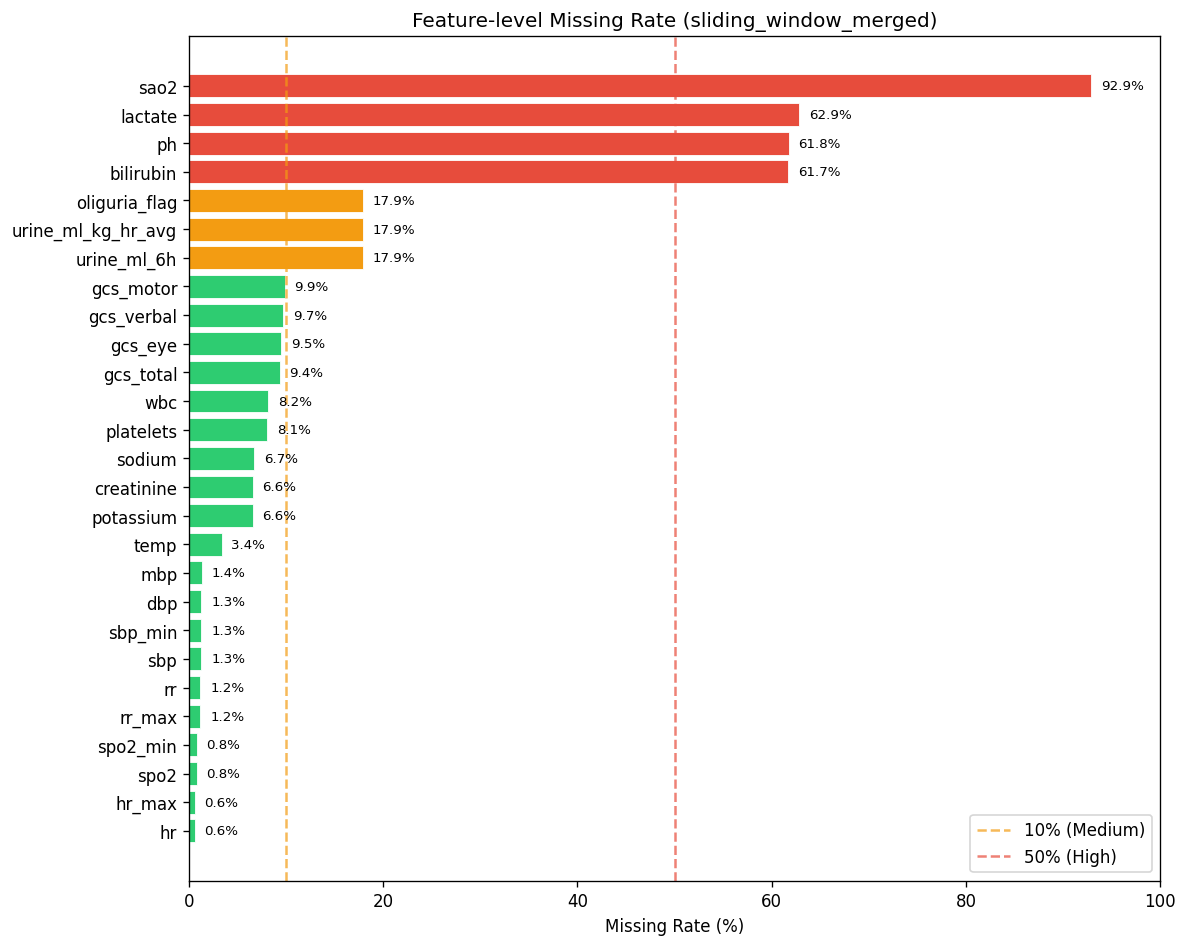


=== 결측 등급별 피처 분류 ===
  Low  (< 10%): 20개 → ['hr', 'hr_max', 'spo2', 'spo2_min', 'rr_max', 'rr', 'sbp', 'sbp_min', 'dbp', 'mbp', 'temp', 'potassium', 'creatinine', 'sodium', 'platelets', 'wbc', 'gcs_total', 'gcs_eye', 'gcs_verbal', 'gcs_motor']
  Med  (10-50%): 3개 → ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag']
  High (≥ 50%): 4개 → ['bilirubin', 'ph', 'lactate', 'sao2']


In [ ]:
# ── 9-1. 전체 피처별 결측률 바 차트 ──
missing_pct = df_windows[feature_cols].isna().mean().sort_values(ascending=True) * 100

# 카테고리 분류용 색상
def get_color(val):
    if val < 10:
        return '#2ecc71'   # Low  → 녹색
    elif val < 50:
        return '#f39c12'   # Med  → 주황
    else:
        return '#e74c3c'   # High → 빨강

colors = [get_color(v) for v in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)

# 바 끝에 수치 표시
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# 10%, 50% 임계선
ax.axvline(10, color='#f39c12', linestyle='--', alpha=0.7, label='10% (Medium)')
ax.axvline(50, color='#e74c3c', linestyle='--', alpha=0.7, label='50% (High)')

ax.set_xlabel('Missing Rate (%)')
ax.set_title('Feature-level Missing Rate (sliding_window_merged)')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

# 요약 테이블
print("\n=== 결측 등급별 피처 분류 ===")
low  = missing_pct[missing_pct < 10].index.tolist()
med  = missing_pct[(missing_pct >= 10) & (missing_pct < 50)].index.tolist()
high = missing_pct[missing_pct >= 50].index.tolist()
print(f"  Low  (< 10%): {len(low)}개 → {low}")
print(f"  Med  (10-50%): {len(med)}개 → {med}")
print(f"  High (≥ 50%): {len(high)}개 → {high}")

### 9-2. 시간대(observation_hour)별 결측률 히트맵

> ICU 체류 초반(6-12h)에는 Lab 결과가 아직 안 나와 결측이 많고,  
> 후반(48h+)에는 측정 빈도 저하 또는 퇴실로 인한 결측이 증가할 수 있다.  
> **시간에 따른 결측 패턴**이 있으면 시간 자체가 informative missingness가 된다.

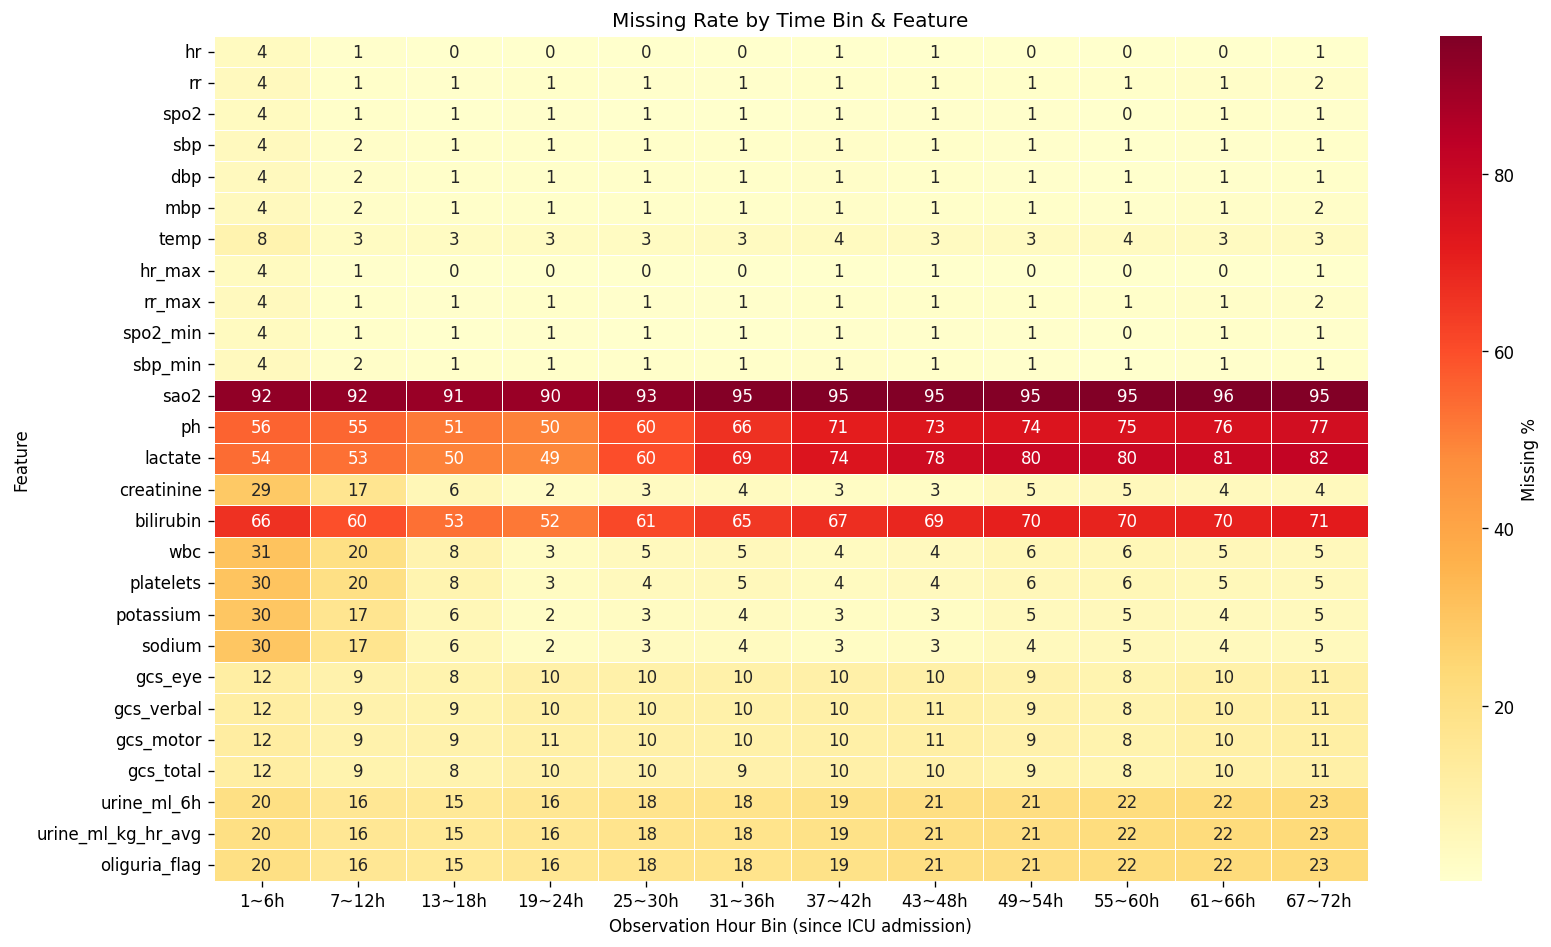


=== 시간대별 결측 변화 해석 ===
  후반 증가 (>5%p): {'lactate': np.float64(27.4), 'ph': np.float64(21.3)}
  후반 감소 (>5%p): {'wbc': np.float64(-25.8), 'sodium': np.float64(-25.5), 'platelets': np.float64(-25.5), 'potassium': np.float64(-25.3), 'creatinine': np.float64(-24.6)}


In [ ]:
# ── 9-2. 시간대별 결측률 히트맵 ──

# 6h 간격으로 버케팅하여 가독성 확보
hour_bins = list(range(6, 78, 6))  # [6, 12, 18, ..., 72]

df_windows['hour_bin'] = pd.cut(
    df_windows['observation_hour'],
    bins=[5] + hour_bins,
    labels=[f'{h-5}~{h}h' for h in hour_bins]
)

# 버킷별 결측률 계산
missing_by_hour = df_windows.groupby('hour_bin', observed=True)[feature_cols].apply(
    lambda x: x.isna().mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    missing_by_hour.T,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Missing %'},
    ax=ax
)
ax.set_title('Missing Rate by Time Bin & Feature')
ax.set_xlabel('Observation Hour Bin (since ICU admission)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

# 시간에 따른 변화 요약
print("\n=== 시간대별 결측 변화 해석 ===")
early = missing_by_hour.iloc[0]  # 첫 번째 버킷
late  = missing_by_hour.iloc[-1]  # 마지막 버킷
diff  = late - early

increasing = diff[diff > 5].sort_values(ascending=False)
decreasing = diff[diff < -5].sort_values()

if len(increasing) > 0:
    print(f"  후반 증가 (>5%p): {dict(increasing.round(1))}")
if len(decreasing) > 0:
    print(f"  후반 감소 (>5%p): {dict(decreasing.round(1))}")
if len(increasing) == 0 and len(decreasing) == 0:
    print("  → 대부분 피처에서 시간대별 결측률 변화가 5%p 이내로 안정적")


### 9-3. 레이블(이벤트 유무)별 결측률 비교

> **핵심 질문**: "이벤트가 발생한 윈도우에서 결측이 더 많은가 / 적은가?"  
> - 이벤트 군과 비이벤트 군의 결측률 차이가 크면 → **MNAR (Missing Not At Random)** 가능성  
> - MNAR이면 단순 imputation이 bias를 유발할 수 있으므로, **missingness indicator** 자체를 피처로 추가하는 것이 중요

In [ ]:
# ── 9-3. 레이블별 결측률 비교 (composite_next_24h 기준) ──
# 24h composite 이벤트 기준으로 Event vs No-Event 결측률 비교
label_col = 'composite_next_24h'

event_mask = df_windows[label_col] == 1

miss_event = df_windows.loc[event_mask, feature_cols].isna().mean() * 100
miss_noevent = df_windows.loc[~event_mask, feature_cols].isna().mean() * 100
miss_diff = miss_event - miss_noevent  # 양수 = 이벤트 군에서 더 많이 결측

# 정렬: 차이 절대값 큰 순
order = miss_diff.abs().sort_values(ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# 왼쪽: 두 그룹 비교 바 차트
y_pos = np.arange(len(order))
axes[0].barh(
    y_pos - 0.2,
    miss_noevent[order],
    height=0.4,
    label=f'No Event (n={(~event_mask).sum():,})',
    color='#3498db',
    alpha=0.8,
)
axes[0].barh(
    y_pos + 0.2,
    miss_event[order],
    height=0.4,
    label=f'Event (n={event_mask.sum():,})',
    color='#e74c3c',
    alpha=0.8,
)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(order)
axes[0].set_xlabel('Missing Rate (%)')
axes[0].set_title(f'Missing Rate: Event vs No-Event ({label_col})')
axes[0].legend(loc='lower right')

# 오른쪽: 차이 (Event - No Event)
colors_diff = ['#e74c3c' if v > 0 else '#3498db' for v in miss_diff[order]]
axes[1].barh(y_pos, miss_diff[order], color=colors_diff, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Difference (%p): Event - No Event')
axes[1].set_title('Missing Rate Gap (+=more missing in Event)')

# 유의미한 차이 표시
for i, (feat, val) in enumerate(miss_diff[order].items()):
    if abs(val) > 2:
        axes[1].text(
            val + (0.3 if val > 0 else -0.3),
            i,
            f'{val:+.1f}',
            va='center',
            fontsize=7,
            ha='left' if val > 0 else 'right',
        )

plt.tight_layout()
plt.show()

# MNAR 위험 피처 출력
print("\n=== MNAR 위험 분석 (|차이| > 3%p) ===")
risky = miss_diff[miss_diff.abs() > 3].sort_values(key=abs, ascending=False)

if len(risky) > 0:
    for feat, val in risky.items():
        direction = "Event에서 더 많이 결측" if val > 0 else "Event에서 더 적게 결측(=검사 더 자주)"
        print(f"{feat}: {val:+.1f}%p ({direction})")
    print("\n→ 이 피처들은 missingness indicator를 반드시 추가하고,")
    print("imputation 시 label 정보가 leak되지 않도록 주의")
else:
    print("→ 모든 피처에서 이벤트 유무에 따른 결측률 차이가 3%p 이내로 양호")


### 9-4. 피처 간 결측 상관관계 (Co-missingness)

> 같은 검사 패널에서 나오는 항목들은 동시에 결측/관측된다.  
> 높은 상관관계를 보이는 피처 그룹은 **하나의 missingness indicator**로 묶어 관리 가능.

In [ ]:
# ── 9-4. Co-missingness 상관 히트맵 ──
# 결측 여부 (1=결측, 0=관측) 간의 상관계수
miss_indicator = df_windows[feature_cols].isna().astype(int)
miss_corr = miss_indicator.corr()

# 항상 결측이거나 항상 관측인 컬럼은 상관계수 NaN → 제거
valid_cols = miss_corr.dropna(how='all').columns
miss_corr = miss_corr.loc[valid_cols, valid_cols]

fig, ax = plt.subplots(figsize=(12, 10))
mask_upper = np.triu(np.ones_like(miss_corr, dtype=bool), k=1)  # 상삼각 마스킹

sns.heatmap(
    miss_corr,
    mask=mask_upper,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Missingness Correlation'},
    ax=ax,
)
ax.set_title('Co-missingness Correlation Matrix')
plt.tight_layout()
plt.show()

# 강한 상관 그룹 자동 추출
print("\n=== 강한 Co-missingness 그룹 (|r| > 0.8) ===")
pairs = []
for i in range(len(miss_corr)):
    for j in range(i + 1, len(miss_corr)):
        r = miss_corr.iloc[i, j]
        if abs(r) > 0.8:
            pairs.append((miss_corr.index[i], miss_corr.columns[j], r))

if pairs:
    for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f"{a} ↔ {b}: r={r:.3f}")
    print("\n→ 이들은 동일 검사 패널이므로 missingness indicator 1개로 대표 가능")
else:
    print("→ |r| > 0.8인 쌍이 없음 (개별 missingness indicator 필요)")


---
### 9-5. 모델링 전략 요약

위 EDA 결과를 종합한 **피처별 결측 처리 전략**:

#### A. 피처 분류 및 Imputation 전략

| 등급 | 결측률 | 피처 | 권장 전략 |
|------|--------|------|-----------|
| **Low** | < 10% | hr, rr, spo2, sbp, dbp, mbp, temp, hr_max, rr_max, spo2_min, sbp_min, creatinine, wbc, platelets, potassium, sodium, gcs_* | **Forward-fill → Median imputation**. 결측이 적으므로 단순 전략으로 충분 |
| **Medium** | 10-50% | urine_ml_6h, urine_ml_kg_hr_avg, oliguria_flag | **Forward-fill → Median + Missingness indicator** 추가. 결측 자체가 정보를 담고 있을 수 있음 |
| **High** | ≥ 50% | sao2, ph, lactate, bilirubin | 아래 별도 전략 참조 |

#### B. High-missing 피처 (sao2, ph, lactate, bilirubin) 처리 옵션

1. **Option 1: 제거 (Drop)**
   - `sao2`는 92.9% 결측 → ABG 검사를 받는 환자만 값 존재 → **제거 강력 권장**
   - `ph`, `lactate`, `bilirubin`은 ~62% 결측 → ABG/간기능 패널에 의존

2. **Option 2: Missingness indicator만 사용**
   - `has_abg = 1 if ph is not NaN else 0` 형태의 binary feature로 변환
   - ABG 검사를 오더하는 행위 자체가 환자 중증도의 proxy → 강력한 피처가 될 수 있음

3. **Option 3: 조건부 Imputation** (lactate, bilirubin만)
   - 결측 시 median으로 채우되 `{col}_missing` indicator 반드시 추가
   - 모델이 "값이 있다 = 비정상적이어서 검사를 했다"를 학습하도록 유도

#### C. Imputation 순서 (권장)

```
1. 환자 내 시간순 forward-fill (같은 stay_id 내에서 직전 윈도우 값 이월)
2. 환자 내 backward-fill (첫 윈도우 결측 보완)
3. 전체 train set median으로 나머지 결측 채움 (test set에는 train median 적용)
```

> **주의**: Imputation 통계량(median 등)은 반드시 **train set에서만** 계산하여 test set에 적용해야 data leakage를 방지

#### D. Missingness Indicator 추가 대상

- **필수**: High-missing 피처 (ph, lactate, bilirubin) → 검사 오더 여부 자체가 중증도 signal
- **권장**: Medium-missing 피처 (urine 계열) → 모니터링 강도 signal
- **Co-missingness 그룹**: 같은 패널(예: ph+lactate+sao2)은 indicator 1개로 통합 가능

#### E. Tree-based 모델 vs Neural Network

| 모델 유형 | 결측 처리 |
|-----------|-----------|
| **XGBoost / LightGBM** | NaN을 네이티브로 처리 가능. Imputation 없이도 학습 가능하지만, forward-fill 정도는 적용 권장 |
| **LSTM / Transformer** | NaN 입력 불가. 반드시 imputation 후 missingness indicator를 추가 피처로 입력 |
| **공통** | sao2 제거, missingness indicator 추가는 모든 모델에 적용 |

#### F. 최종 피처 목록 (권장)

```python
# 제거 대상
drop_cols = ['sao2']  # 92.9% 결측, ABG 전용

# 최종 연속형 피처 (23개)
numeric_features = [
    # Vital (11)
    'hr', 'rr', 'spo2', 'sbp', 'dbp', 'mbp', 'temp',
    'hr_max', 'rr_max', 'spo2_min', 'sbp_min',
    # Lab (8) - sao2 제외
    'ph', 'lactate', 'creatinine', 'bilirubin',
    'wbc', 'platelets', 'potassium', 'sodium',
    # GCS (1) - total만 사용 (sub-score 간 다중공선성)
    'gcs_total',
    # Urine (3)
    'urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag',
]

# Missingness indicator (추가 피처)
miss_indicators = [
    'miss_ph_lactate',    # ABG 패널 결측 여부
    'miss_bilirubin',     # 간기능 패널 결측 여부
    'miss_urine',         # 소변 모니터링 결측 여부
]

# 정적 피처
static_features = ['anchor_age', 'gender', 'observation_hour']
```